Database connection

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError

load_dotenv(find_dotenv())

def connect_to_db():
    host = os.getenv("DB_HOST", "localhost")
    port = os.getenv("DB_PORT", "5432")
    database = os.getenv("DB_NAME")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")

    if not all([database, user, password]):
        print("Σφάλμα: Δεν βρέθηκαν οι απαραίτητες μεταβλητές στο .env!")
        return None

    try:
        connection_uri = f"postgresql://{user}:{password}@{host}:{port}/{database}"
        engine = create_engine(connection_uri)
        with engine.connect() as connection:
            print(f"Επιτυχής σύνδεση στη βάση '{database}' στο host '{host}'!")
        return engine

    except SQLAlchemyError as e:
        print(f"Σφάλμα κατά τη σύνδεση στη ΒΔ: {e}")
        return None


print("Εκκίνηση σύνδεσης με τη βάση...")
engine = connect_to_db()

if engine is None:
    print("Τερματισμός προγράμματος λόγω αποτυχίας σύνδεσης.")
    exit(1)

Εκκίνηση σύνδεσης με τη βάση...
Επιτυχής σύνδεση στη βάση 'thesis_db' στο host 'dell-micro'!


Import data to dataframe

In [2]:
import pandas as pd

query = "SELECT match_id, x_loc, y_loc, distance_to_goal, angle_to_goal, is_goal FROM understat_shots_normalized"
us_shots = pd.read_sql(query, con=engine)

In [3]:
query = "SELECT match_id, x_loc, y_loc, distance_to_goal, angle_to_goal, is_goal FROM statsbomb_shots_normalized"
sb_shots = pd.read_sql(query, con=engine)

Remove overlapping matches

In [4]:
query = "SELECT understat_match_id FROM mapping_overlapping_matches"
overlapping_matches = pd.read_sql_query(query, con=engine)
overlapping_matches.head()

,understat_match_id
0,923
1,662
2,727
3,890
4,644


In [5]:
print(f"Αρχικές εγγραφές us_shots: {len(us_shots)}")
overlapping_matches_list = overlapping_matches['understat_match_id'].unique()

# Αφαίρεση overlapping matches από το us_shots
us_shots = us_shots[~us_shots['match_id'].isin(overlapping_matches_list)].reset_index(drop=True)

print(f"Overlapping matches: {len(overlapping_matches_list)}")
print(f"Εγγραφές μετά την αφαίρεση: {len(us_shots)}")

Αρχικές εγγραφές us_shots: 605446
Overlapping matches: 1576
Εγγραφές μετά την αφαίρεση: 566725


Drop 'match_id' from DataFrames

In [6]:
us_shots.drop(['match_id'], axis=1, inplace=True)
sb_shots.drop(['match_id'], axis=1, inplace=True)

print(f"{list(us_shots)} και {list(sb_shots)}")

['x_loc', 'y_loc', 'distance_to_goal', 'angle_to_goal', 'is_goal'] και ['x_loc', 'y_loc', 'distance_to_goal', 'angle_to_goal', 'is_goal']


Merge 2 dataframes

In [7]:
shots = pd.concat([us_shots, sb_shots], ignore_index=True)
print(f"Μέγεθος Understat: {len(us_shots)}")
print(f"Μέγεθος StatsBomb: {len(sb_shots)}")
print(f"Μέγεθος Συνολικό : {len(shots)}")

Μέγεθος Understat: 566725
Μέγεθος StatsBomb: 55857
Μέγεθος Συνολικό : 622582


Plot the shots

<Axes: xlabel='x_loc', ylabel='y_loc'>

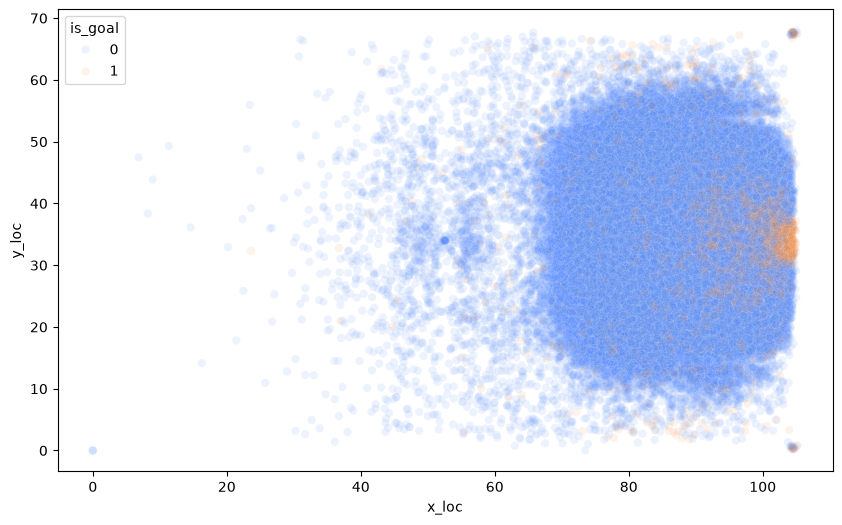

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_loc', y='y_loc', data=shots, hue='is_goal', alpha=0.1)

Convert is_goal to boolean

In [9]:
shots.dtypes

x_loc               float64
y_loc               float64
distance_to_goal    float64
angle_to_goal       float64
is_goal               int64
dtype: object

In [10]:
shots['is_goal'] = shots['is_goal'].astype(bool)
shots.dtypes
print(f"Γκολ: {len(shots[shots['is_goal'] == True ])} - ({shots['is_goal'].mean():.2%})")
print(f"Όχι Γκολ: {(~shots['is_goal']).sum()} - ({(~shots['is_goal']).mean():.2%})")
print("Class Imbalanced")

Γκολ: 60584 - (9.73%)
Όχι Γκολ: 561998 - (90.27%)
Class Imbalanced


Model Training

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

X = shots.drop(columns=['is_goal', 'x_loc', 'y_loc'])
y = shots['is_goal']

model = LogisticRegression()
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

predictions = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]

Metrics

In [12]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

print(f"Log Loss: {log_loss(y, predictions):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions):.04f}")

Log Loss: 0.2818
ROC AUC:  0.7411
Brier Score:  0.0792


Model version 2 (with tweaks)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        l1_ratio=0,
        C = 100,
        solver='newton-cholesky',
        random_state=42
    ),
)

predictions2 = cross_val_predict(model2, X, y, cv=skf, method='predict_proba')[:,1]

In [14]:
print(f"Log Loss: {log_loss(y, predictions2):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions2):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions2):.04f}")

Log Loss: 0.2818
ROC AUC:  0.7411
Brier Score:  0.0792
